In [1]:
# Import libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [2]:
# Define the path
path = 'C:\\Users\\User\\Documents\\Career Foundry\\Data Analytics Immersion\\Data Immersion 4. Python Fundamentals for Data Analysts\\Instacart Basket Analysis'

In [3]:
# Import the most up-to-date project data
orders_products_all = pd.read_pickle(os.path.join(path, '02 Data', 'Prepared Data', 'orders_products_all.pkl'))

In [4]:
orders_products_all.columns

Index(['user_id', 'first_name', 'surname', 'gender', 'state', 'age',
       'date_joined', 'num_dependants', 'family_status', 'income', 'order_id',
       'order_number', 'orders_day_of_week', 'order_hour_of_day',
       'days_since_prior_order', 'product_id', 'add_to_cart_order',
       'reordered', 'product_name', 'aisle_id', 'department_id', 'prices',
       'price_range_loc', 'busiest_day', 'busiest_days_category',
       'busiest_period_of_day', 'max_order', 'loyalty_flag',
       'avg_price_per_user', 'spending_flag', 'median_days_since_order',
       'order_frequency_flag', '_merge'],
      dtype='object')

# 3 You need to provide the Instacart senior stakeholders with descriptive findings about sales. Create a histogram of the “order_hour_of_day” column.
In a markdown cell beneath your histogram, describe what the histogram demonstrates.

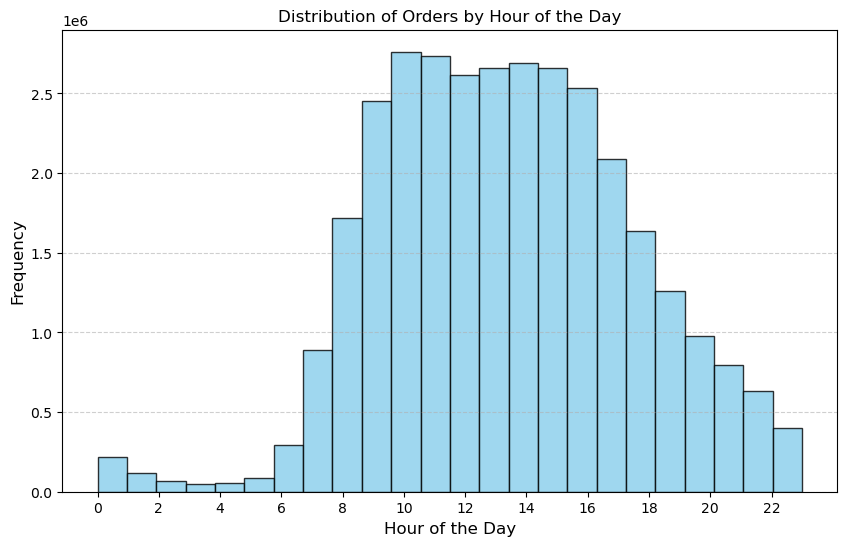

In [6]:
# Create a histogram for 'order_hour_of_day' and assign it to a variable
hist_hourly_orders = orders_products_all['order_hour_of_day'].plot.hist(
    bins=24,
    figsize=(10, 6),
    color='skyblue',  # Consistent with updated colors in the bar chart
    edgecolor='black',
    alpha=0.8,
    title='Distribution of Orders by Hour of the Day'
)

# Add labels
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(range(0, 24, 2))  # Show ticks for every two hours
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Display the plot
plt.show()

# The histogram shows that the peak order activity occurs between 10:00 and 15:00, indicating that mid-morning to early afternoon is the busiest time for customers. Order frequency declines steadily after 15:00, with the least activity during late-night and early-morning hours (0:00–6:00). This trend reflects customer behavior tied to typical daily routines and can help stakeholders optimize staffing, delivery schedules, and promotions during peak hours.

# 4 The marketing team is curious about the distribution of orders among customers in terms of loyalty. Create a bar chart from the “loyalty_flag” column.

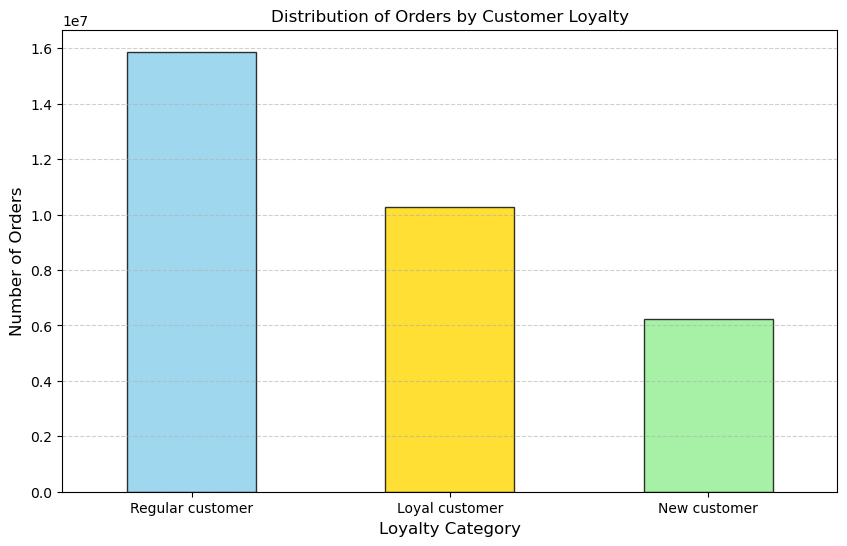

In [9]:
# Create a histogram for 'order_hour_of_day' and assign it to a variable
bar_loyalty = orders_products_all['loyalty_flag'].value_counts().plot.bar(
    figsize=(10, 6),
    color=['skyblue', 'gold', 'lightgreen'],
    edgecolor='black',
    alpha=0.8,
    title='Distribution of Orders by Customer Loyalty'
)
# Add labels
plt.xlabel('Loyalty Category', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=0)  # Ensure x-axis labels are horizontal
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Display the plot
plt.show()

# The bar chart shows that the majority of orders come from regular customers, followed by loyal customers, with new customers contributing the least. This highlights the importance of retaining regular customers, as they form the foundation of Instacart's sales. Loyal customers also represent a valuable group, warranting targeted incentives to maintain their engagement. The smaller proportion of orders from new customers suggests an opportunity to focus on strategies for attracting and converting them into repeat buyers, such as personalized offers and welcome programs. Overall, focusing on retaining existing customers while encouraging new customers to shop more often could drive long-term sales growth.

# 5 Check whether there’s a difference in expenditure (the “prices” column) depending on the hour of the day. (Hint: To check this, you need to use an accurate sample for your line chart!)

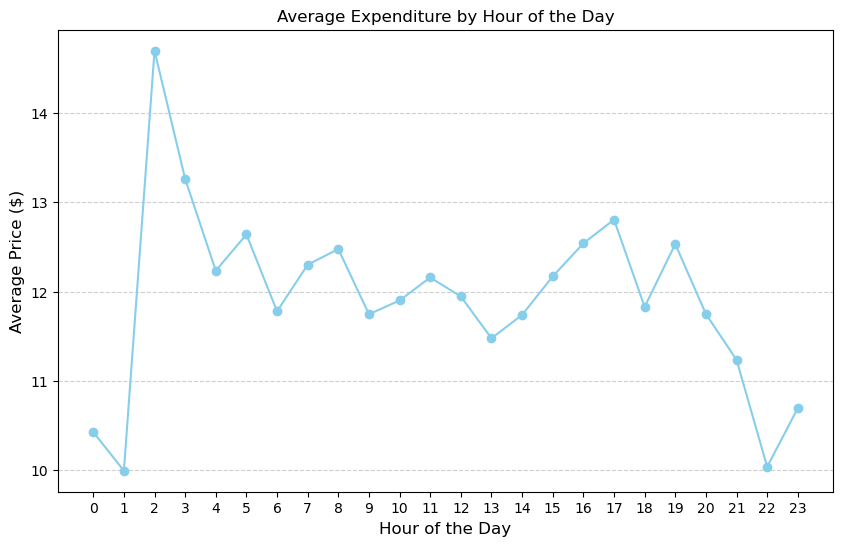

In [12]:
# Group the data by 'order_hour_of_day' and calculate the mean of 'prices'
hourly_prices = orders_products_all.groupby('order_hour_of_day')['prices'].mean()

# Create a line chart assign it to a variable
line_hourly_prices = hourly_prices.plot(
    kind='line',
    figsize=(10, 6),
    marker='o',
    linestyle='-',
    color='skyblue',
    title='Average Expenditure by Hour of the Day'
)

# Add labels and formatting
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Average Price ($)', fontsize=12)
plt.xticks(range(0, 24))  # Ensure all 24 hours are displayed on the x-axis
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Display the plot
plt.show()

# There are notable variations in expenditure depending on the hour of the day, with late-night orders tending toward higher-value purchases and daytime orders reflecting more typical spending patterns.

# 6 Now that you have information about customers, you need to conduct some exploratory analysis of customer demographics to inform the targeted marketing campaigns. First, determine whether there’s a connection between age and family situation by creating a line chart exploring the connections between age and number of dependents:
In a markdown cell beneath your line chart, describe what the line chart shows.

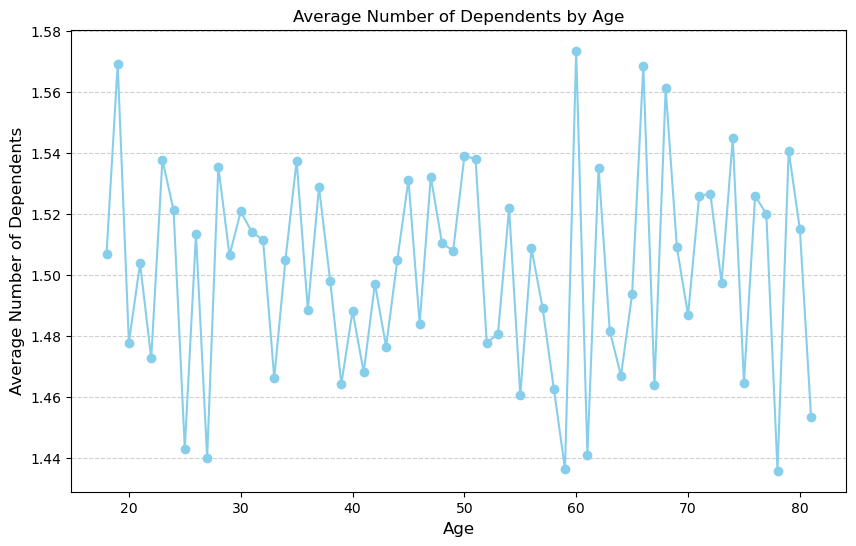

In [15]:
# Group data by 'age' and calculate the mean of 'num_dependants'
age_dependants = orders_products_all.groupby('age')['num_dependants'].mean()

# Create a line chart
line_age_dependants = age_dependants.plot(
    kind='line', 
    figsize=(10, 6), 
    marker='o', 
    linestyle='-', 
    color='skyblue', 
    title='Average Number of Dependents by Age'
)

# Add labels and grid
plt.xlabel('Age', fontsize=12)
plt.ylabel('Average Number of Dependents', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Show the plot
plt.show()

# The chart shows fluctuations, indicating that there is no clear connection between age and the number of dependents. Other factorsb might provide more meaningful insights into demographic trends.

# 7 You’ll also need to explore whether there’s a connection between age and spending power (income). To visualize this relationship, create a scatterplot using the sns.scatterplot() function.
In a markdown cell beneath your scatterplot, describe what the scatterplot shows.

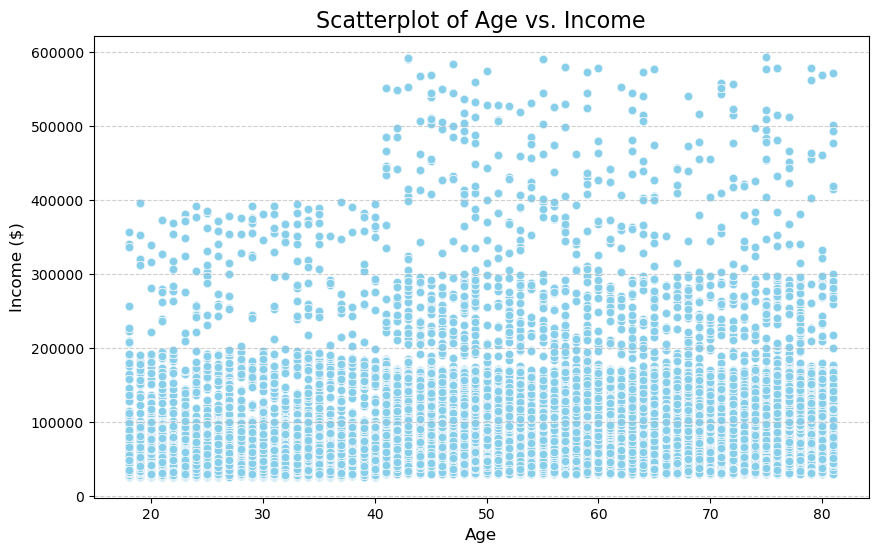

In [18]:
# Create a scatterplot to visualize the relationship between age and income
plt.figure(figsize=(10, 6))
scatter_age_income = sns.scatterplot(data=orders_products_all, x='age', y='income', alpha=0.6, color='skyblue')

# Add labels and title
plt.title('Scatterplot of Age vs. Income', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Income ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Show the plot
plt.show()

# The scatterplot shows a positive correlation between age and income, where income tends to increase with age, particularly from the 20s to the 40s, before stabilizing. While the trend is not perfectly linear, it suggests that age is moderately associated with higher income, likely reflecting career progression and increased earning potential over time. However, a bar graph using age bins might better illustrate this pattern.

C:\Users\User\AppData\Local\Temp\ipykernel_8424\2373058572.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_bin_income = orders_products_all.groupby('age_bin')['income'].mean()


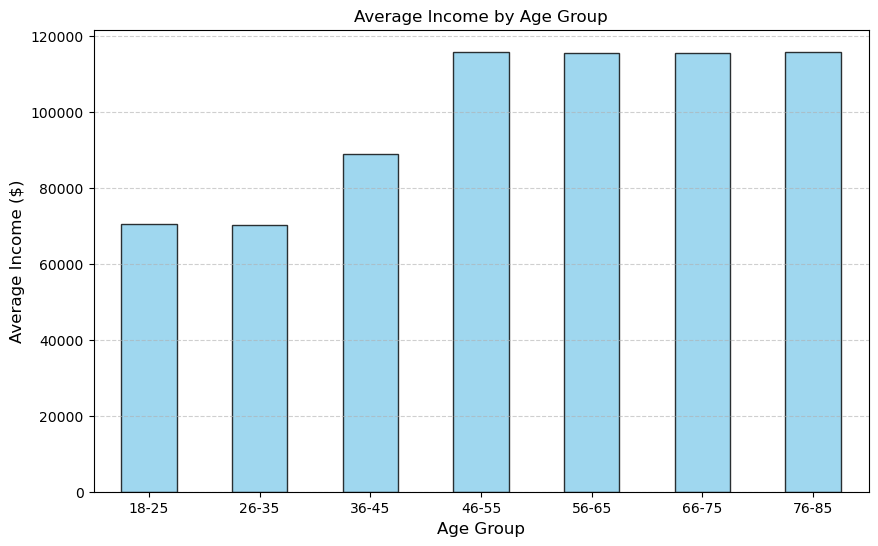

In [20]:
# Create age bins
bins = [18, 25, 35, 45, 55, 65, 75, 85]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66-75', '76-85']
orders_products_all['age_bin'] = pd.cut(orders_products_all['age'], bins=bins, labels=labels, right=False)

# Calculate average income for each age bin
age_bin_income = orders_products_all.groupby('age_bin')['income'].mean()

# Create a bar graph and name it
bar_age_income = age_bin_income.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black',
    alpha=0.8,
    figsize=(10, 6),
    title='Average Income by Age Group'
)

# Add labels and grid
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Average Income ($)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Show the plot
plt.show()

# The bar chart shows that average income increases with age, peaking in the 46–55 age group, but it is not significantly higher than the older age groups. After this peak, income remains stable, suggesting consistent earnings or retirement income across later life stages.

In [22]:
# Export visualizations as .png files

# 1. Export hist_hourly_orders
hist_hourly_orders.get_figure().savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'hist_hourly_orders.png'), dpi=300, bbox_inches='tight')

# 2. Export bar_loyalty
bar_loyalty.get_figure().savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'bar_loyalty.png'), dpi=300, bbox_inches='tight')

# 3. Export line_hourly_prices
line_hourly_prices.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'line_hourly_prices.png'), dpi=300, bbox_inches='tight')

# 4. Export line_age_dependants
line_age_dependants.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'line_age_dependants.png'), dpi=300, bbox_inches='tight')

# 5. Export scatter_age_income
scatter_age_income.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'scatter_age_income.png'), dpi=300, bbox_inches='tight')

# 6. Export bar_age_income
bar_age_income.get_figure().savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'bar_age_income.png'), dpi=300, bbox_inches='tight')

print("All visualizations have been successfully exported.")

All visualizations have been successfully exported.
